In [7]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 1. Load Bank Marketing Dataset
print("Loading data...")
url = "bank-additional-full.csv"
data = pd.read_csv(url, sep=';')

# 2. Handle missing values
# ('unknown' is treated as missing; replacing with mode for simplicity)
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].replace('unknown', data[col].mode()[0])

# 3. Encode categorical variables
le = LabelEncoder()
data['y'] = le.fit_transform(data['y']) # Target variable

# One-hot encoding for features
X = pd.get_dummies(data.drop('y', axis=1), drop_first=True)
y = data['y']

# 4. Split data: 70% Train, 15% Validation, 15% Test
# First split to get 70% train and 30% temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
# Second split to divide the 30% temp into 15% val and 15% test equivalent
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp)

# 5. Feature Scaling (Fit on Train ONLY to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for XGBoost to preserve feature names for importance plotting
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Data shapes - Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

Loading data...
Data shapes - Train: (28830, 47), Val: (6179, 47), Test: (6179, 47)


Training GBDT and generating visualizations...


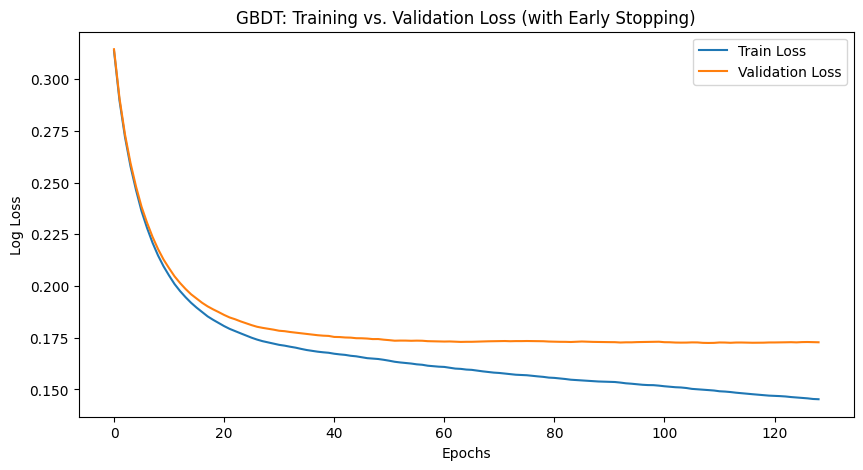

<Figure size 1000x600 with 0 Axes>

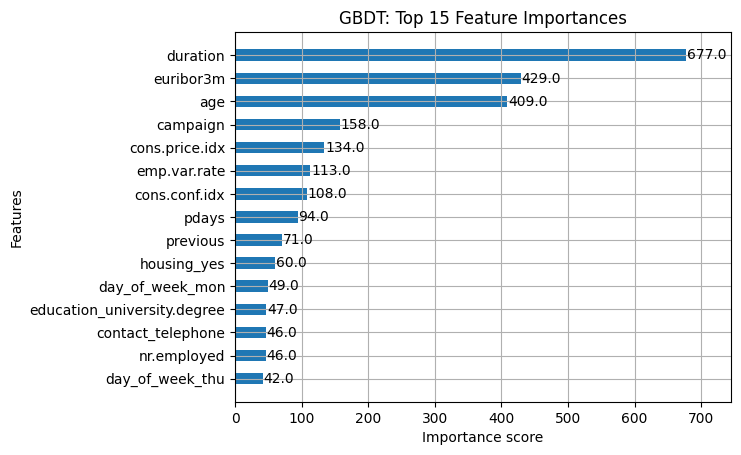

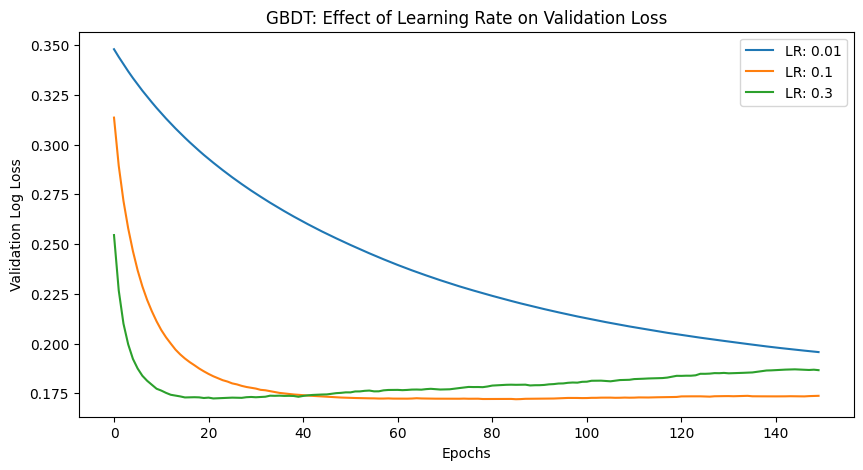

In [8]:
print("Training GBDT and generating visualizations...")

# 1. Train Model with eval_set and early stopping
start_time_xgb = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    verbose=False
)
xgb_train_time = time.time() - start_time_xgb

# 2. Visualization: Training vs. Validation Loss
results = xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Loss')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Epochs')
plt.title('GBDT: Training vs. Validation Loss (with Early Stopping)')
plt.show()

# 3. Visualization: Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=15, height=0.5, importance_type='weight')
plt.title('GBDT: Top 15 Feature Importances')
plt.show()

# 4. Visualization: Effect of Learning Rate
learning_rates = [0.01, 0.1, 0.3]
plt.figure(figsize=(10, 5))

for lr in learning_rates:
    model = xgb.XGBClassifier(n_estimators=150, learning_rate=lr, random_state=42)
    model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)
    val_loss = model.evals_result()['validation_0']['logloss']
    plt.plot(range(len(val_loss)), val_loss, label=f'LR: {lr}')

plt.legend()
plt.ylabel('Validation Log Loss')
plt.xlabel('Epochs')
plt.title('GBDT: Effect of Learning Rate on Validation Loss')
plt.show()

# Save predictions for final comparison
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

Training MLP and generating visualizations...


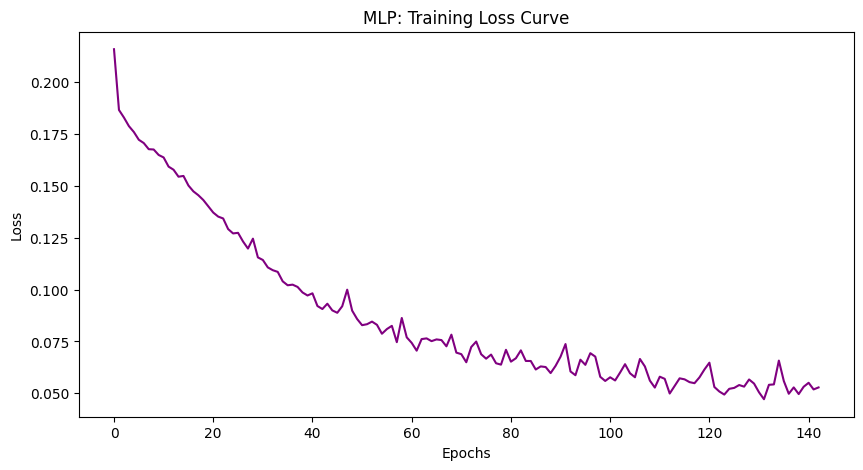

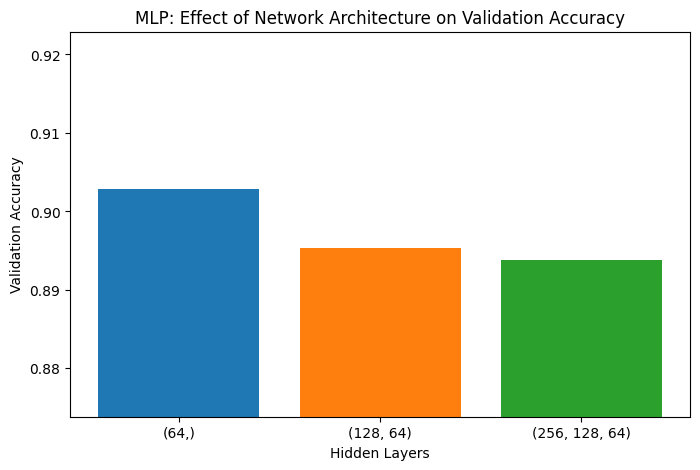


--- Exploring MLP Activation & Learning Rate on Validation Set ---
Activation: relu | LR: 0.001 | Val Accuracy: 0.9060
Activation: relu | LR: 0.010 | Val Accuracy: 0.8924
Activation: relu | LR: 0.100 | Val Accuracy: 0.8958
Activation: tanh | LR: 0.001 | Val Accuracy: 0.9021
Activation: tanh | LR: 0.010 | Val Accuracy: 0.8899
Activation: tanh | LR: 0.100 | Val Accuracy: 0.9001


In [9]:
print("Training MLP and generating visualizations...")

# 1. Train base MLP
start_time_mlp = time.time()
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time_mlp

# 2. Visualization: Training Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, color='purple')
plt.title('MLP: Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# 3. Visualization: Effect of Network Depth/Width
architectures = [(64,), (128, 64), (256, 128, 64)]
val_accuracies = []

for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation='relu', max_iter=150, random_state=42)
    model.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val_scaled))
    val_accuracies.append(val_acc)

plt.figure(figsize=(8, 5))
arch_labels = [str(a) for a in architectures]
plt.bar(arch_labels, val_accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(min(val_accuracies) - 0.02, max(val_accuracies) + 0.02)
plt.title('MLP: Effect of Network Architecture on Validation Accuracy')
plt.xlabel('Hidden Layers')
plt.ylabel('Validation Accuracy')
plt.show()

# 4. Explore Activation & Learning Rate (Text Output)
print("\n--- Exploring MLP Activation & Learning Rate on Validation Set ---")
for act in ['relu', 'tanh']:
    for lr in [0.001, 0.01, 0.1]:
        model = MLPClassifier(hidden_layer_sizes=(64,), activation=act, learning_rate_init=lr, max_iter=100, random_state=42)
        model.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_val, model.predict(X_val_scaled))
        print(f"Activation: {act:4s} | LR: {lr:5.3f} | Val Accuracy: {acc:.4f}")

# Save predictions for final comparison
y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

In [10]:
# Create evaluation function
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'AUC-PR': average_precision_score(y_true, y_prob)
    }

# Gather metrics
xgb_metrics = get_metrics(y_test, y_pred_xgb, y_prob_xgb)
mlp_metrics = get_metrics(y_test, y_pred_mlp, y_prob_mlp)

xgb_metrics['Training Time (s)'] = xgb_train_time
mlp_metrics['Training Time (s)'] = mlp_train_time

# Build side-by-side comparison table
comparison_df = pd.DataFrame([xgb_metrics, mlp_metrics], index=['GBDT (XGBoost)', 'MLP (Neural Network)']).T

print("\n=== Final Model Comparison on Test Set ===")
display(comparison_df.round(4))


=== Final Model Comparison on Test Set ===


,GBDT (XGBoost),MLP (Neural Network)
Accuracy,0.9212,0.8972
Precision,0.6850,0.5401
Recall,0.5560,0.5905
F1-score,0.6138,0.5642
AUC-PR,0.6871,0.5545
Training Time (s),1.1513,57.8334
